# Russell 2000 Rebalance: Cumulative Abnormal Return Event Study

**Method:** Fama-French 5-Factor adjusted event study.

**t = 0:** Rank Date (~April 30 each year).

**Windows:**
- Estimation: days −250 to −81 (fit FF5 betas)
- Event: days −80 to +20 (pre-rank pre-positioning + post-rank drift)

**Performance:** prices are stored as Parquet (columnar). Each group query reads only its own tickers — never the full 11k-ticker matrix.

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import pyarrow.parquet as pq
from pathlib import Path

sns.set_theme(style='whitegrid', font_scale=1.1)
PROCESSED_DIR  = Path('../../data/processed')
RAW_PRICES_DIR = Path('../../data/raw/prices')

## 1. One-Time Conversion: CSV → Parquet

Run this cell once. After `FINALIZED_PRICES.parquet` exists, this cell is instant.

In [2]:
PARQUET_PATH = PROCESSED_DIR / 'FINALIZED_PRICES.parquet'

if not PARQUET_PATH.exists():
    print('Converting CSV → Parquet (one-time, takes ~30s)...')
    _prices = pd.read_csv(
        RAW_PRICES_DIR / 'FINALIZED_PRICES_CSV.csv',
        index_col=0,
        parse_dates=True,
        na_values=['#N/A N/A', '#N/A', 'N/A', '#NA'],
        encoding='utf-8-sig'
    )
    _prices.index = pd.to_datetime(_prices.index)
    _prices = _prices.apply(pd.to_numeric, errors='coerce')
    _prices.sort_index().to_parquet(PARQUET_PATH)
    del _prices
    print(f'Saved → {PARQUET_PATH}')
else:
    print(f'Parquet already exists ({PARQUET_PATH.stat().st_size / 1e6:.1f} MB) — skipping conversion.')

# Read column names from Parquet metadata (essentially free — no data loaded)
PRICE_COLS = set(pq.read_schema(PARQUET_PATH).names)
print(f'Tickers available in Parquet: {len(PRICE_COLS):,}')

Parquet already exists (124.1 MB) — skipping conversion.
Tickers available in Parquet: 11,546


## 2. Load Fama-French 5 Factors

In [3]:
FF5 = pd.read_csv(
    PROCESSED_DIR / 'F-F_Research_Data_5_Factors_2x3_daily.csv',
    skiprows=2, header=None,
    names=['Date', 'Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA', 'RF']
)
FF5['Date'] = pd.to_datetime(FF5['Date'].astype(str), format='%Y%m%d')
FF5 = FF5.set_index('Date') / 100

FACTOR_COLS = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']
print(f'FF5: {FF5.shape[0]:,} days  |  {FF5.index.min().date()} → {FF5.index.max().date()}')
FF5.head(3)

FF5: 15,666 days  |  1963-07-02 → 2025-09-30


,Mkt-RF,SMB,HML,RMW,CMA,RF
Date,,,,,,
1963-07-02,0.0079,-0.0026,0.0026,-0.0007,-0.0020,0.0001
1963-07-03,0.0063,-0.0017,-0.0009,0.0018,-0.0034,0.0001
1963-07-05,0.0040,0.0008,-0.0027,0.0009,-0.0034,0.0001


## 3. Load Events

In [4]:
events = pd.read_csv(str(PROCESSED_DIR / 'russell_events.csv'))
events['Rank_Date'] = pd.to_datetime(events['Rank_Date'])

print(f'Events: {len(events):,} rows, {events["Ticker"].nunique():,} unique tickers')
print()
print(events['Classification'].value_counts())

Events: 7,517 rows, 4,469 unique tickers

Classification
TO_RMICRO      2983
FROM_RMICRO    2251
FROM_R1000     1631
TO_R1000        652
Name: count, dtype: int64


## 4. Event Study Parameters

In [5]:
EST_START   = -250
EST_END     = -81
EVT_START   = -80
EVT_END     = 20
MIN_EST_OBS = 120

EVENT_DAYS  = list(range(EVT_START, EVT_END + 1))

GROUP_COLORS = {
    'ADD: FROM R1000':   '#1565C0',
    'ADD: FROM RMICRO':  '#2E7D32',
    'DELETE: TO R1000':  '#E65100',
    'DELETE: TO RMICRO': '#B71C1C',
}

## 5. Core Event Study Function

Reads **only this group's tickers** from Parquet on each call — never the full price matrix.

In [6]:
def run_event_study(events_subset: pd.DataFrame) -> pd.DataFrame:
    """
    1. Reads only unique tickers for this group from Parquet (columnar — fast).
    2. Filters returns to FF5 (NYSE) trading days — Bloomberg includes holidays; FF5 does not.
    3. For each event: aligns trading days → fits FF5 OLS → computes AR
       → cumulative AR path: cum_ar[d] = prod(1 + AR[-80..d]) - 1.

    Returns DataFrame: rows = events, columns = EVENT_DAYS (-80 … +20).
    """
    # --- Load only the tickers this group needs ---
    needed  = [t for t in events_subset['Ticker'].unique() if t in PRICE_COLS]
    missing = events_subset['Ticker'].nunique() - len(needed)
    if missing:
        print(f'  Warning: {missing} tickers not found in Parquet, will be skipped.')

    prices_grp  = pd.read_parquet(PARQUET_PATH, columns=needed)
    returns_grp = prices_grp.pct_change(fill_method=None)
    # Align to NYSE/FF5 calendar — Bloomberg includes US holiday dates; FF5 does not
    returns_grp = returns_grp[returns_grp.index.isin(FF5.index)]

    car_paths   = []
    n_no_ticker = 0
    n_short     = 0
    n_est_fail  = 0
    n_evt_gap   = 0

    for _, row in events_subset.iterrows():
        tkr       = row['Ticker']
        rank_date = row['Rank_Date']

        if tkr not in returns_grp.columns:
            n_no_ticker += 1
            continue

        tkr_ret = returns_grp[tkr].dropna()
        if len(tkr_ret) == 0:
            n_no_ticker += 1
            continue

        # --- Align to trading-day offsets around rank_date ---
        rank_idx = tkr_ret.index.searchsorted(rank_date)
        est_s = rank_idx + EST_START
        est_e = rank_idx + EST_END + 1
        evt_s = rank_idx + EVT_START
        evt_e = rank_idx + EVT_END + 1

        if est_s < 0 or evt_e > len(tkr_ret):
            n_short += 1
            continue

        est_dates = tkr_ret.index[est_s:est_e]
        evt_dates = tkr_ret.index[evt_s:evt_e]

        if len(evt_dates) != len(EVENT_DAYS):
            n_short += 1
            continue

        # --- Estimation window: fit FF5 ---
        est_ff5    = FF5.reindex(est_dates)[FACTOR_COLS + ['RF']].dropna()
        common_est = tkr_ret.index.intersection(est_ff5.index)

        if len(common_est) < MIN_EST_OBS:
            n_est_fail += 1
            continue

        est_excess = tkr_ret.loc[common_est] - FF5.loc[common_est, 'RF']
        X_est      = sm.add_constant(FF5.loc[common_est, FACTOR_COLS])

        try:
            model = sm.OLS(est_excess, X_est).fit()
        except Exception:
            n_est_fail += 1
            continue

        # --- Event window: compute AR ---
        evt_ff5 = FF5.reindex(evt_dates)[FACTOR_COLS + ['RF']]
        if evt_ff5.isna().any().any():
            n_evt_gap += 1
            continue

        evt_excess = tkr_ret.loc[evt_dates].values - evt_ff5['RF'].values
        X_evt      = sm.add_constant(evt_ff5[FACTOR_COLS], has_constant='add')
        ar         = evt_excess - model.predict(X_evt).values

        # --- Cumulative AR path starting from day -80 ---
        cum_ar = np.cumprod(1 + ar) - 1
        car_paths.append(cum_ar)

    n_ok = len(car_paths)
    print(f'  Included: {n_ok:,}  |  No price data: {n_no_ticker}  |  '
          f'Short window: {n_short}  |  Est. fail: {n_est_fail}  |  Event gap: {n_evt_gap}')

    return pd.DataFrame(car_paths, columns=EVENT_DAYS)

## 6. Run for All Four Groups

Each call loads only that group's tickers from Parquet.

In [7]:
groups = {
    'ADD: FROM R1000':   events[events['Classification'] == 'FROM_R1000'],
    'ADD: FROM RMICRO':  events[events['Classification'] == 'FROM_RMICRO'],
    'DELETE: TO R1000':  events[events['Classification'] == 'TO_R1000'],
    'DELETE: TO RMICRO': events[events['Classification'] == 'TO_RMICRO'],
}

results = {}
for name, grp in groups.items():
    print(f'\n--- {name}  ({len(grp):,} events) ---')
    results[name] = run_event_study(grp)


--- ADD: FROM R1000  (1,631 events) ---
  Included: 1,423  |  No price data: 10  |  Short window: 198  |  Est. fail: 0  |  Event gap: 0

--- ADD: FROM RMICRO  (2,251 events) ---
  Included: 2,031  |  No price data: 16  |  Short window: 204  |  Est. fail: 0  |  Event gap: 0

--- DELETE: TO R1000  (652 events) ---
  Included: 571  |  No price data: 2  |  Short window: 79  |  Est. fail: 0  |  Event gap: 0

--- DELETE: TO RMICRO  (2,983 events) ---
  Included: 2,658  |  No price data: 31  |  Short window: 294  |  Est. fail: 0  |  Event gap: 0


## 7. Combined CAR Path Plot (4 Groups)

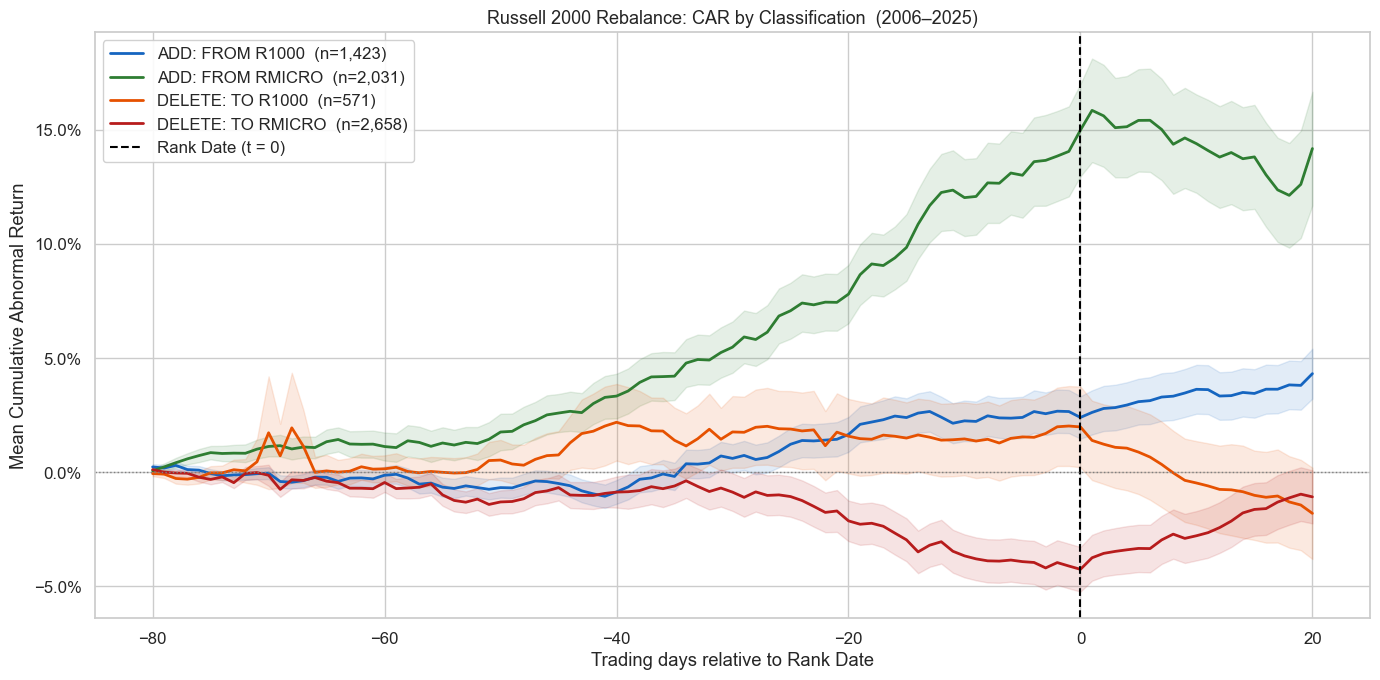

In [8]:
fig, ax = plt.subplots(figsize=(14, 7))

for name, car_df in results.items():
    if car_df.empty:
        continue
    mean_car = car_df.mean()
    se       = car_df.std(ddof=1) / np.sqrt(len(car_df))
    color    = GROUP_COLORS[name]

    ax.plot(EVENT_DAYS, mean_car, label=f'{name}  (n={len(car_df):,})', color=color, lw=2)
    ax.fill_between(EVENT_DAYS, mean_car - se, mean_car + se, alpha=0.12, color=color)

ax.axvline(0, color='black', linestyle='--', lw=1.5, label='Rank Date (t = 0)')
ax.axhline(0, color='gray',  linestyle=':',  lw=1)
ax.set_xlabel('Trading days relative to Rank Date')
ax.set_ylabel('Mean Cumulative Abnormal Return')
ax.set_title('Russell 2000 Rebalance: CAR by Classification  (2006–2025)', fontsize=13)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
ax.legend(framealpha=0.9)
plt.tight_layout()
plt.show()

## 8. Individual Group Plots (2 × 2 Grid)

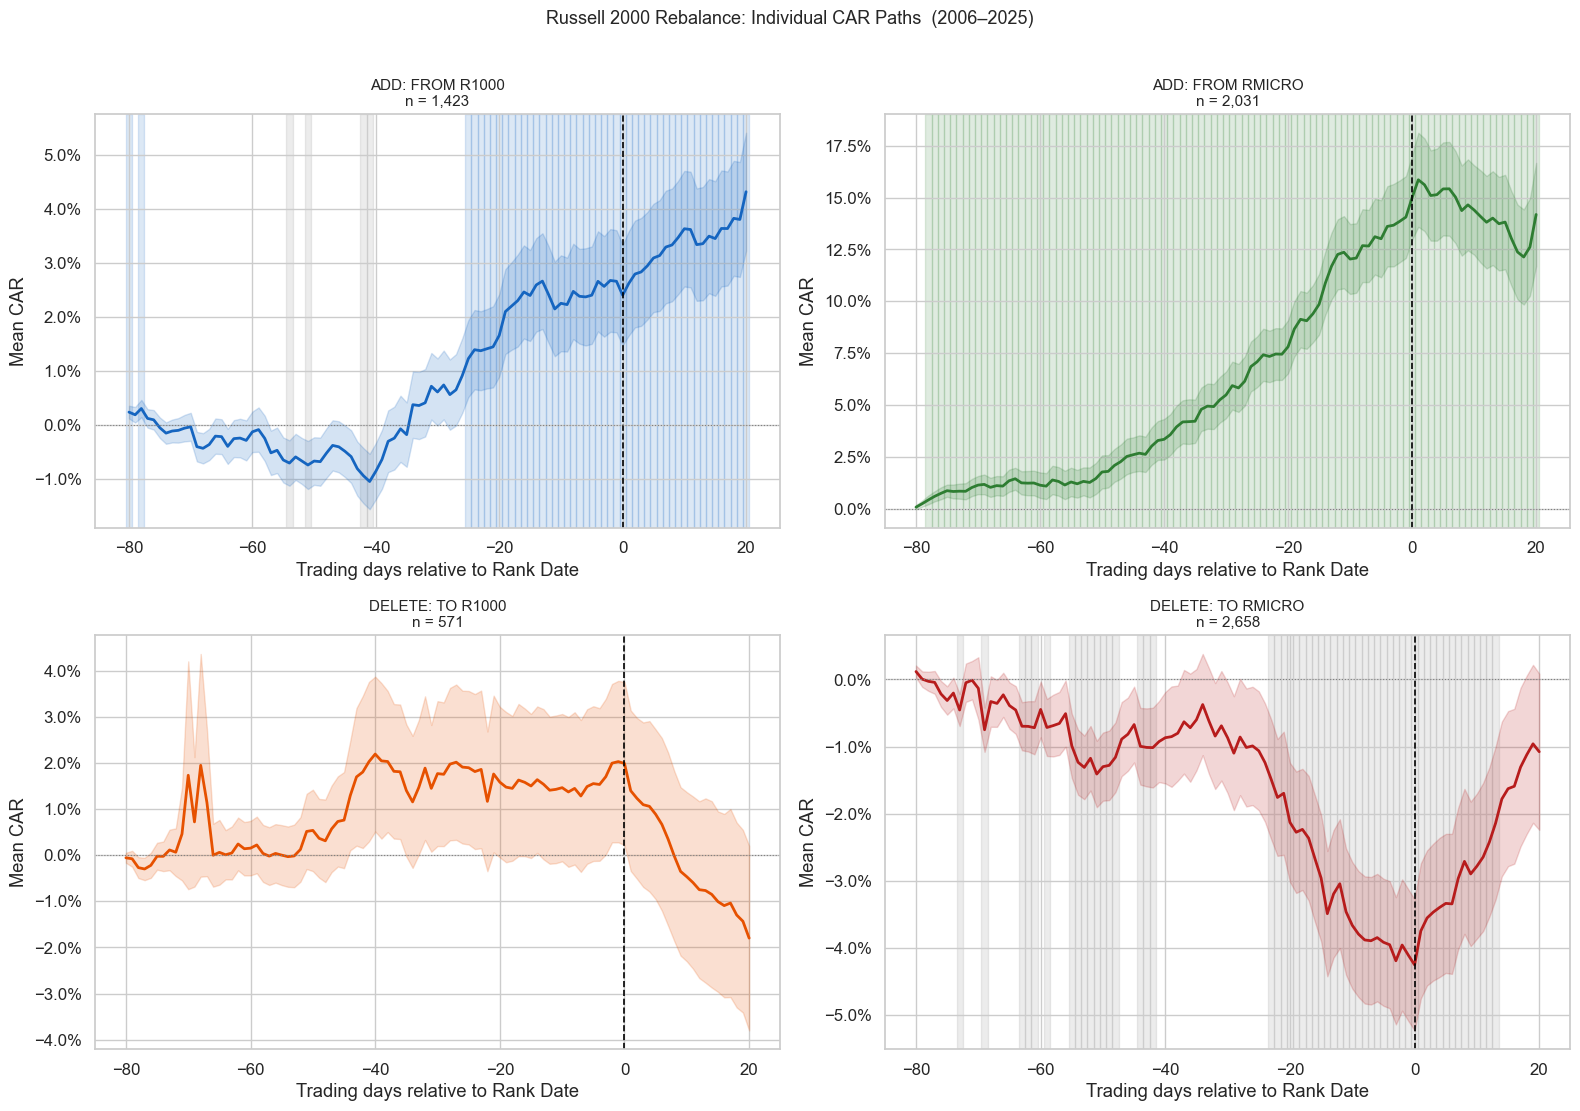

In [9]:
TCRIT = 1.65  # one-sided 10% significance

fig, axes = plt.subplots(2, 2, figsize=(16, 11), sharey=False)
axes = axes.flatten()

for ax, (name, car_df) in zip(axes, results.items()):
    if car_df.empty:
        ax.set_title(f'{name}\n(no data)')
        continue

    mean_car = car_df.mean()
    se       = car_df.std(ddof=1) / np.sqrt(len(car_df))
    tstat    = mean_car / se.replace(0, np.nan)
    color    = GROUP_COLORS[name]

    for d in EVENT_DAYS:
        if tstat[d] >=  TCRIT:
            ax.axvspan(d - 0.5, d + 0.5, alpha=0.15, color=color,  zorder=0)
        elif tstat[d] <= -TCRIT:
            ax.axvspan(d - 0.5, d + 0.5, alpha=0.15, color='gray', zorder=0)

    ax.plot(EVENT_DAYS, mean_car, color=color, lw=2)
    ax.fill_between(EVENT_DAYS, mean_car - se, mean_car + se, alpha=0.18, color=color)
    ax.axvline(0, color='black', linestyle='--', lw=1.2)
    ax.axhline(0, color='gray',  linestyle=':',  lw=0.8)
    ax.set_title(f'{name}\nn = {len(car_df):,}', fontsize=11)
    ax.set_xlabel('Trading days relative to Rank Date')
    ax.set_ylabel('Mean CAR')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))

plt.suptitle('Russell 2000 Rebalance: Individual CAR Paths  (2006–2025)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 9. Statistical Summary Table

In [10]:
KEY_DAYS = [-40, -20, -10, -1, 0, 5, 10, 20]

rows = []
for name, car_df in results.items():
    if car_df.empty:
        continue
    for d in KEY_DAYS:
        vals = car_df[d]
        mean = vals.mean()
        se   = vals.std(ddof=1) / np.sqrt(len(vals))
        t    = mean / se if se > 0 else np.nan
        rows.append({
            'Group':    name,
            'Day':      d,
            'Mean CAR': f'{mean:+.2%}',
            't-stat':   f'{t:+.2f}',
            'n':        len(vals),
            'Sig*':     '*' if not np.isnan(t) and abs(t) >= TCRIT else '',
        })

summary = pd.DataFrame(rows)
display(
    summary.pivot_table(
        index='Day', columns='Group',
        values=['Mean CAR', 't-stat', 'Sig*'],
        aggfunc='first'
    )
)
print('* |t| ≥ 1.65  (one-sided 10%)')

Mean CAR                                                      \
Group ADD: FROM R1000 ADD: FROM RMICRO DELETE: TO R1000 DELETE: TO RMICRO   
Day                                                                         
-40            -0.86%           +3.34%           +2.19%            -0.87%   
-20            +1.66%           +7.81%           +1.58%            -2.13%   
-10            +2.25%          +12.03%           +1.46%            -3.66%   
-1             +2.66%          +14.06%           +2.03%            -4.11%   
 0             +2.40%          +14.99%           +1.99%            -4.25%   
 5             +3.09%          +15.42%           +0.89%            -3.33%   
 10            +3.64%          +14.40%           -0.47%            -2.78%   
 20            +4.32%          +14.18%           -1.80%            -1.08%   

                 Sig*                                                      \
Group ADD: FROM R1000 ADD: FROM RMICRO DELETE: TO R1000 DELETE: TO RMICRO   
Day                                                                         
-40                                  *                                      
-20                 *                *                                  *   
-10                 *                *                                  *   
-1                  *                *                                  *   
 0                  *                *                                  *   
 5                  *                *                                  *   
 10                 *                *                                  *   
 20                 *                *                                      

               t-stat                                                      
Group ADD: FROM R1000 ADD: FROM RMICRO DELETE: TO R1000 DELETE: TO RMICRO  
Day                                                                        
-40             -1.65            +3.42            +1.31             -1.27  
-20             +2.17            +6.11            +0.97             -2.40  
-10             +2.53            +7.14            +0.92             -3.89  
-1              +2.82            +7.13            +1.16             -4.19  
 0              +2.59            +7.40            +1.12             -4.35  
 5              +3.08            +6.87            +0.48             -3.22  
 10             +3.39            +6.68            -0.26             -2.57  
 20             +3.95            +5.70            -0.90             -0.93

* |t| ≥ 1.65  (one-sided 10%)
